Anjolaoluwa Otegbade

For this project, I am using the Mushroom Classification dataset from Kaggle:
https://www.kaggle.com/datasets/uciml/mushroom-classification

The goal of this project is to build a machine learning model that can classify mushrooms as either edible or poisonous based on their physical characteristics.

Challenge:
How can we minimize the risk of incorrectly classifying a poisonous mushroom as edible and which features are most critical in preventing this mistake?

This problem is important because misclassifying a poisonous mushroom as edible could have serious consequences on a person's life. Because of this, the project will focus not just on accuracy, but also on avoiding dangerous mistakes.
This is a supervised classification problem since the dataset includes labeled examples. The dataset contains descriptions of mushroom samples, where each row represents a mushroom and each column represents a physical characteristic such as cap shape, odor, or gill color. Most of the features are categorical, so they will need to be converted into a format that machine learning models can use.

In [41]:
import pandas as pd
df = pd.read_csv("mushrooms.csv")
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [42]:
df.shape

(8124, 23)

The dataset contains 8124 rows and 23 features

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

All features in the dataset are of object type. There are no numerical features present. Each column represents a different characteristic of the mushroom.

In [11]:
df.isnull().sum()
(df == '?').sum()

class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

Here there are no standard null values in the dataset. But, the feature stalk root contains 2480 missing values represented by the symbol '?'. We need to handle this during the data cleaning stage

In [12]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print()

class
['p' 'e']

cap-shape
['x' 'b' 's' 'f' 'k' 'c']

cap-surface
['s' 'y' 'f' 'g']

cap-color
['n' 'y' 'w' 'g' 'e' 'p' 'b' 'u' 'c' 'r']

bruises
['t' 'f']

odor
['p' 'a' 'l' 'n' 'f' 'c' 'y' 's' 'm']

gill-attachment
['f' 'a']

gill-spacing
['c' 'w']

gill-size
['n' 'b']

gill-color
['k' 'n' 'g' 'p' 'w' 'h' 'u' 'e' 'b' 'r' 'y' 'o']

stalk-shape
['e' 't']

stalk-root
['e' 'c' 'b' 'r' '?']

stalk-surface-above-ring
['s' 'f' 'k' 'y']

stalk-surface-below-ring
['s' 'f' 'y' 'k']

stalk-color-above-ring
['w' 'g' 'p' 'n' 'b' 'e' 'o' 'c' 'y']

stalk-color-below-ring
['w' 'p' 'g' 'b' 'n' 'e' 'y' 'o' 'c']

veil-type
['p']

veil-color
['w' 'n' 'o' 'y']

ring-number
['o' 't' 'n']

ring-type
['p' 'e' 'l' 'f' 'n']

spore-print-color
['k' 'n' 'u' 'h' 'w' 'r' 'o' 'y' 'b']

population
['s' 'n' 'a' 'v' 'y' 'c']

habitat
['u' 'g' 'm' 'd' 'p' 'w' 'l']



| Feature     | Type        | Example Values | Missing Values | Notes                    |
| ----------- | ----------- | -------------- | -------------- | ------------------------ |
| class       | categorical | e, p           | 0              | target variable          |
| cap-shape   | categorical | x, b, s, f     | 0              | mushroom cap shape       |
| cap-surface | categorical | s, y, f, g     | 0              | texture of cap           |
| cap-color   | categorical | n, y, w, g     | 0              | cap color categories     |
| bruises     | categorical | t, f           | 0              | presence of bruises      |
| odor        | categorical | p, a, l, n     | 0              | likely important feature |
| stalk-root  | categorical | e, c, b, r, ?  | 2480           | contains missing values  |
| habitat     | categorical | u, g, m, d     | 0              | mushroom environment     |


In [13]:
df['class'].value_counts()

class
e    4208
p    3916
Name: count, dtype: int64

The dataset is relatively balanced between edible and poisonous mushrooms. Since both classes appear in similar amounts, class imbalance is not expected to significantly affect model performance.

Since all features are categorical, traditional numerical outliers do not apply. Outliers are usually values that are much larger or smaller than the rest of the data.

The target variable in this dataset is class.

- e = edible mushrooms
- p = poisonous mushrooms

This is a binary classification problem because there are only two possible outcomes.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

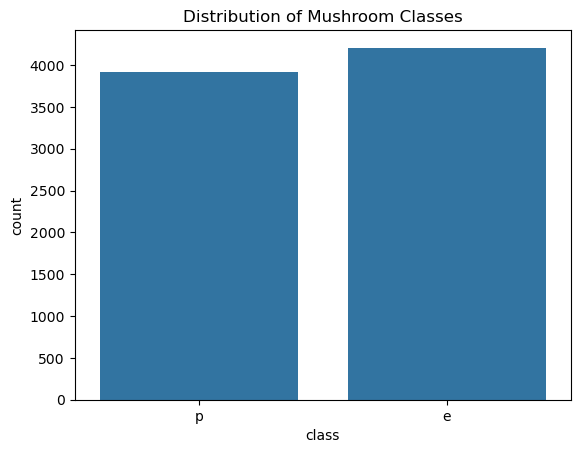

In [15]:
sns.countplot(x='class', data=df)
plt.title("Distribution of Mushroom Classes")
plt.show()

The graph shows the number of edible and poisonous mushrooms in the dataset. The classes appear relatively balanced

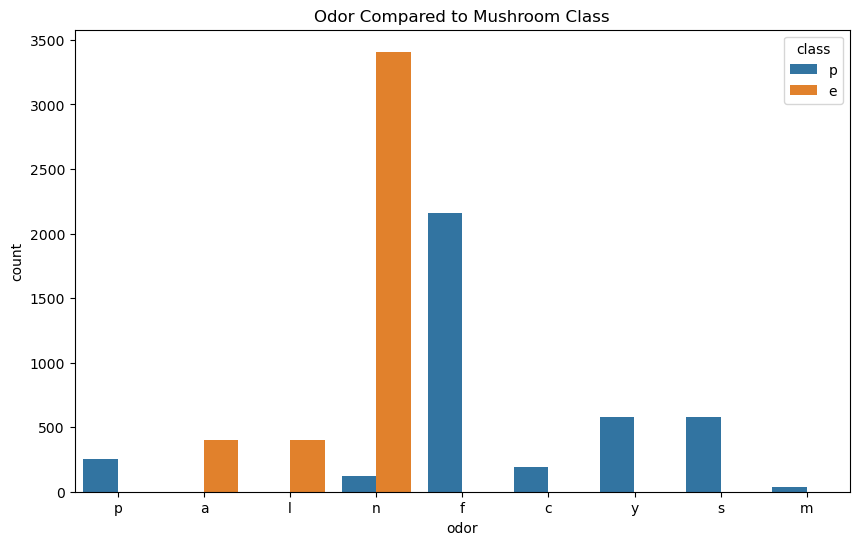

In [16]:
plt.figure(figsize=(10,6))
sns.countplot(x='odor', hue='class', data=df)
plt.title("Odor Compared to Mushroom Class")
plt.show()

Odor appears to vary significantly between edible and poisonous mushrooms. Certain odor categories seem to occur more often in poisonous mushrooms.

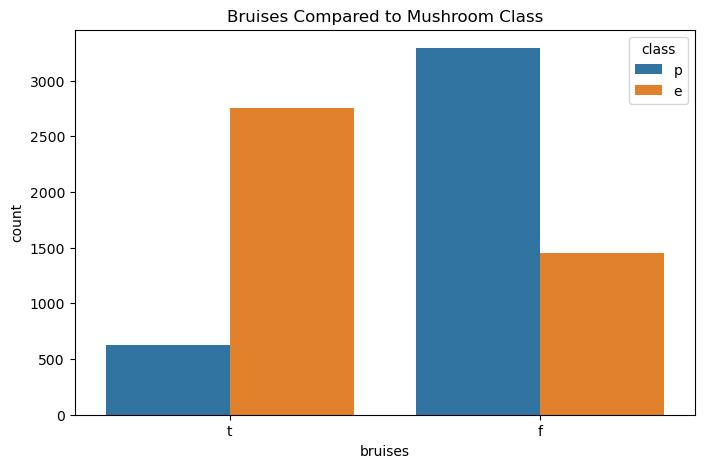

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x='bruises', hue='class', data=df)
plt.title("Bruises Compared to Mushroom Class")
plt.show()

Mushrooms with bruises and mushrooms without bruises appear to have different class distributions. This feature may help distinguish edible mushrooms from poisonous mushrooms.





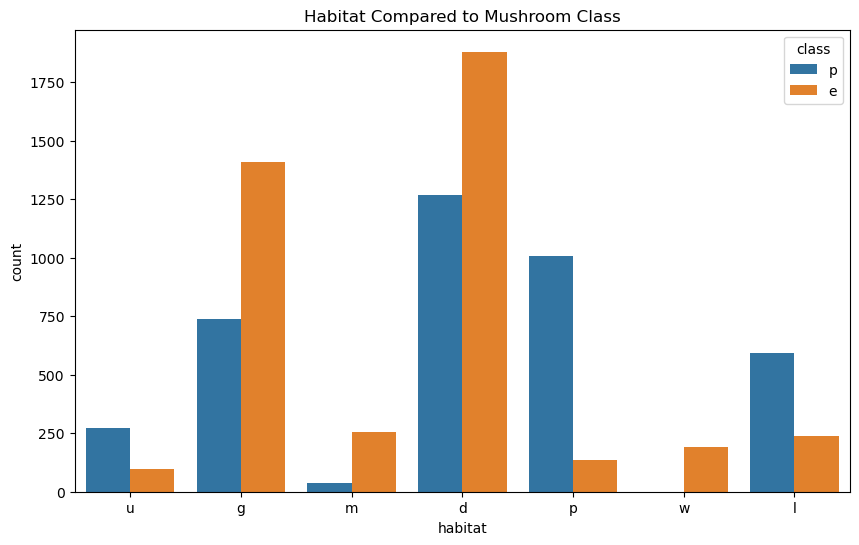

In [18]:
plt.figure(figsize=(10,6))
sns.countplot(x='habitat', hue='class', data=df)
plt.title("Habitat Compared to Mushroom Class")
plt.show()

Different habitats appear to contain different proportions of edible and poisonous mushrooms. Habitat may provide useful information for classification.

 Make comments on what features look most promising for ML task.
Based on the visualizations, odor appears to be one of the most useful features because different odor categories show clear differences between edible and poisonous mushrooms. Bruises also seem helpful since the class distribution changes depending on whether bruises are present. Habitat may also contribute useful information because certain environments appear to contain different proportions of edible and poisonous mushrooms.

*Data Cleaning

In [21]:
df['stalk-root'] = df['stalk-root'].replace('?', 'missing')

The stalk-root feature contained missing values represented by the symbol ?. These values were replaced with the label "missing" so the information could still be included during machine learning.

df['stalk-root'].unique()

After cleaning, the missing values in stalk root were replaced with a new category called "missing".

Rescaling was not necessary for this dataset because all features are categorical rather than numerical. Machine learning models will use encoded category values instead of continuous numeric ranges.

In [28]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,class_p,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,True,False,False,False,False,True,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
1,False,False,False,False,False,True,False,True,False,False,...,True,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,...,True,False,False,False,False,False,True,False,False,False
3,True,False,False,False,False,True,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,False,False,False,False,False,True,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False


One-hot encoding was applied to convert categorical features into numerical columns. This allows machine learning algorithms to process categorical data more effectively

In [29]:
df_encoded.shape

(8124, 96)

In [30]:
X = df_encoded.drop('class_p', axis=1)
y = df_encoded['class_p']

The dataset was split into features (X) and target variable (y). The target variable is class_p, which represents whether a mushroom is poisonous.

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The data was divided into training and testing sets. 80% of the data was used for training and 20% was used for testing.

In [32]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(6499, 95)
(1625, 95)
(6499,)
(1625,)


The training and testing sets were created successfully for machine learning.

## Training The Machine Learning Model

In [34]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

A Decision Tree Classifier was selected for this project because it works well for classification problems and can handle categorical-based patterns after encoding.

In [35]:
y_pred = model.predict(X_test)

The trained model was used to predict mushroom classes on the testing dataset.

In [36]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


Accuracy measures how often the model correctly classified mushrooms in the testing dataset.

In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[843   0]
 [  0 782]]


The confusion matrix shows how many predictions were correct and incorrect. It is especially useful for identifying cases where poisonous mushrooms may have been incorrectly classified as edible.


In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       843
        True       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



The classification report provides precision, recall, and F1-score for each class. These metrics give more detail than accuracy alone.

In [39]:
submission = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

submission.head()

,Actual,Predicted
1971,False,False
6654,True,True
5606,True,True
3332,False,False
6988,True,True


In [40]:
submission.to_csv("mushroom_predictions.csv", index=False)

A submission file was created containing the model predictions on the testing dataset. The file was exported as a CSV for future evaluation or sharing.

Conclusion

This project used the Mushroom Classification dataset to predict if a mushroom is edible or poisonous. After exploring the data, cleaning missing values, encoding categorical features, and training a Decision Tree model, the model achieved very high performance. The results suggest that features such as odor, bruises, and habitat are especially useful for classification. The final model showed excellent prediction accuracy and successfully minimized dangerous classification mistakes.